In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [7]:
df = pd.read_json("C:\\ML-project\\companies_data_final.json")

In [10]:
def clean_and_combine(row):
    elements = []
    if row['operational_name'] and row['operational_name'] != 'Unknown':
        elements.append(str(row['operational_name']))

    try:
        if isinstance(row['primary_naics'], str) and row['primary_naics'] != 'Unknown':
            naics_dict = ast.literal_eval(row['primary_naics'])
            elements.append(naics_dict.get('label', ''))
    except:
        pass
    try:
        if isinstance(row['secondary_naics'], str) and row['secondary_naics'] != 'Unknown':
            naics_dict = ast.literal_eval(row['secondary_naics'])
            elements.append(naics_dict.get('label', ''))
    except:
        pass
    if row['description'] and row['description'] != 'Unknown':
        elements.append(row['description'])

    for col in ['business_model', 'target_markets', 'core_offerings']:
        val = row[col]
        if isinstance(val, list):

            elements.append(" ".join(val))
        elif isinstance(val, str) and val != 'Unknown':
            elements.append(val)

    return " ".join(elements).lower()

df['combined_features'] = df.apply(clean_and_combine, axis=1)

Combined every useful part for the TF-IDF algorithm.

In [11]:
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),   
    max_features=5000     
)

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print(f"Matricea are forma: {tfidf_matrix.shape}")

Matricea are forma: (477, 5000)


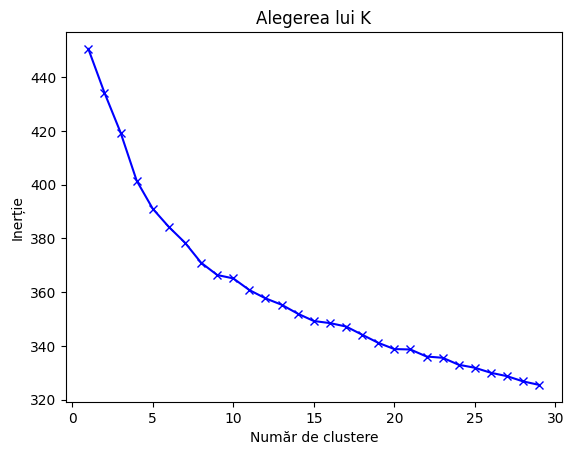

In [ ]:
optim = []
K = range(1, 30)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    optim.append(km.inertia_)
    
plt.plot(K, optim, 'bx-')
plt.xlabel('Număr de clustere')
plt.ylabel('Inerție')
plt.title('Alegerea lui K')
plt.show()

Testing for different k values to see which is better. I decide as 9 is the best value. More clusters means that less calls will be sended to the llm, but to many clusters and we can lose some good companies.

In [22]:
final_km = KMeans(n_clusters=10, random_state=42, n_init=10)
final_km.fit(tfidf_matrix)
df['cluster'] = final_km.labels_
#df.drop(columns=['combined_features'], inplace=True)
print(df['cluster'].value_counts())

cluster
6    85
7    62
9    54
1    50
3    50
0    50
5    44
8    37
4    25
2    20
Name: count, dtype: int64


10 seems to be better than 9 since the number of firms for the greatest cluster decreses from 145 to 85, now all is a bit more balanced.Also dropped the useless column to not waste more space.

In [24]:
for i in range(10):
    cluster_data = df[df['cluster'] == i]
    filename = f"Cluster_{i}.json"
    cluster_data.to_json(filename, orient="records", indent=2)


Breaking the big file into smaller ones.

In [25]:
import joblib
joblib.dump(tfidf_matrix, 'matrix_tfidf.joblib')
joblib.dump(tfidf, 'vectorizer_tfidf.joblib')
joblib.dump(final_km, 'model_kmeans_10.joblib')


['model_kmeans_10.joblib']